In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



ImportError: Error importing numpy: you should not try to import numpy from
        its source directory; please exit the numpy source tree, and relaunch
        your python interpreter from there.

In [2]:
from sklearn.datasets import fetch_openml

print("Fetching MNIST dataset... (first time only, may take a minute)")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_full = mnist.data.astype(np.uint8)
y_full = mnist.target.astype(int)

# Create mnist_0_and_1.csv
mask_01  = (y_full == 0) | (y_full == 1)
X_01     = X_full[mask_01]
y_01     = y_full[mask_01]
df_01    = pd.DataFrame(X_01)
df_01.insert(0, "label", y_01)
df_01.to_csv("mnist_0_and_1.csv", index=False)
print("Saved: mnist_0_and_1.csv")

# Create mnist_3_and_5.csv
mask_35  = (y_full == 3) | (y_full == 5)
X_35     = X_full[mask_35]
y_35     = y_full[mask_35]
df_35    = pd.DataFrame(X_35)
df_35.insert(0, "label", y_35)
df_35.to_csv("mnist_3_and_5.csv", index=False)
print("Saved: mnist_3_and_5.csv")

Fetching MNIST dataset... (first time only, may take a minute)
Saved: mnist_0_and_1.csv
Saved: mnist_3_and_5.csv


In [3]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operation with MCP Neuron for two inputs.
    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.
    Returns:
        state_neuron (list): Output of neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise addition of two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Create output list
    state_neuron = []

    # Step 3: Apply threshold
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample Usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND threshold: both inputs must be 1

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

# Expected: [0, 0, 0, 1]

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [4]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operation with MCP Neuron for two inputs.
    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.
    Returns:
        state_neuron (list): Output of neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise addition of two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Create output list
    state_neuron = []

    # Step 3: Apply threshold
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample Usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR threshold: at least one input must be 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

# Expected: [0, 1, 1, 1]

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# QUESTION 1 - List all the limitations of MCP Neurons
Limitations of MCP Neurons:

1. BINARY INPUTS ONLY
   MCP neurons only accept binary inputs (0 or 1).
   They cannot handle real-valued or continuous inputs,
   which severely limits their use in real-world problems.

2. FIXED WEIGHTS
   All inputs are treated equally — there are no learnable weights.
   The model cannot learn which inputs are more important than others.
   Weights must be manually set by a human expert.

3. MANUALLY SET THRESHOLD
   The threshold T must be hand-crafted by the designer.
   There is no automatic mechanism to find the right threshold.
   This makes it very hard to scale to complex problems.

4. NO LEARNING ABILITY
   MCP neurons cannot learn from data.
   They cannot update themselves based on errors.
   There is no training process whatsoever.

5. CANNOT SOLVE NON-LINEARLY SEPARABLE PROBLEMS
   MCP neurons can only represent linearly separable functions
   (like AND, OR, NOT). They cannot represent XOR because
   XOR is not linearly separable.

6. BINARY OUTPUT ONLY
   Output is always 0 or 1.
   No probability or confidence score is provided.

7. NO BIAS TERM
   Original MCP neuron has no bias, making it less flexible
   in positioning its decision boundary.

8. HIGHLY SIMPLIFIED BIOLOGICAL MODEL
   It is an extreme simplification of how real neurons work.
   Cannot model complex biological behaviours like
   spike timing or synaptic plasticity.

In [5]:
# QUESTION 2 - Can we solve XOR using MCP Neuron?
"""
XOR Truth Table:
  X1 | X2 | XOR Output
  ---|----|-----------
   0 |  0 |     0
   0 |  1 |     1
   1 |  0 |     1
   1 |  1 |     0

Can a SINGLE MCP neuron solve XOR?
  NO — XOR is NOT linearly separable.
  A single straight line cannot separate the 1s from the 0s in XOR.

However, we CAN solve XOR using a COMBINATION of MCP neurons
by decomposing XOR into simpler operations:

  XOR(X1, X2) = AND(OR(X1,X2), NOT(AND(X1,X2)))
              = (X1 OR X2) AND NOT(X1 AND X2)

Logic using if-else rules:
"""

def MCP_XOR(X1, X2):
    """
    Solve XOR using a combination of MCP neuron logic.
    XOR = OR(X1,X2) AND NOT(AND(X1,X2))
    """
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        # Layer 1: OR gate (threshold = 1)
        or_output  = 1 if (X1[i] + X2[i]) >= 1 else 0

        # Layer 1: AND gate (threshold = 2)
        and_output = 1 if (X1[i] + X2[i]) >= 2 else 0

        # Layer 2: NOT AND (inhibitory input)
        not_and    = 1 if and_output == 0 else 0

        # Layer 2: Final AND of (OR result) and (NOT AND result)
        final      = 1 if (or_output + not_and) >= 2 else 0

        state_neuron.append(final)

    return state_neuron


X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

result_xor = MCP_XOR(X1, X2)
print(f"XOR output: {result_xor}")
# Expected: [0, 1, 1, 0]

XOR output: [0, 1, 1, 0]


In [6]:
# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values   # 784 pixels
y = df_0_1["label"].values                   # Labels (0 or 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)

Feature matrix shape: (14780, 784)
Label vector shape:   (14780,)


In [7]:
# QUESTION 1 - What does the shape of X represent?
"""
Answer:
X.shape returns (n_samples, n_features) for example (14780, 784).

- n_samples (rows)   = total number of images in the dataset
                       each row is one image
- n_features (cols)  = 784 = 28 × 28 pixels per image
                       each column is one pixel value (0 to 255)

So X is a 2D matrix where:
  - Each ROW    = one flattened image
  - Each COLUMN = one pixel position across all images
"""

# QUESTION 2 — What does the shape of y represent?
"""
Answer:
y.shape returns (n_samples,) for example (14780,).

- It is a 1D array with one label per image
- Each value is either 0 or 1
  0 = the image is a handwritten digit zero
  1 = the image is a handwritten digit one
"""

print(f"X shape: {X.shape}  →  {X.shape[0]} images, each with {X.shape[1]} pixel features")
print(f"y shape: {y.shape}  →  {y.shape[0]} labels (0 or 1)")

X shape: (14780, 784)  →  14780 images, each with 784 pixel features
y shape: (14780,)  →  14780 labels (0 or 1)


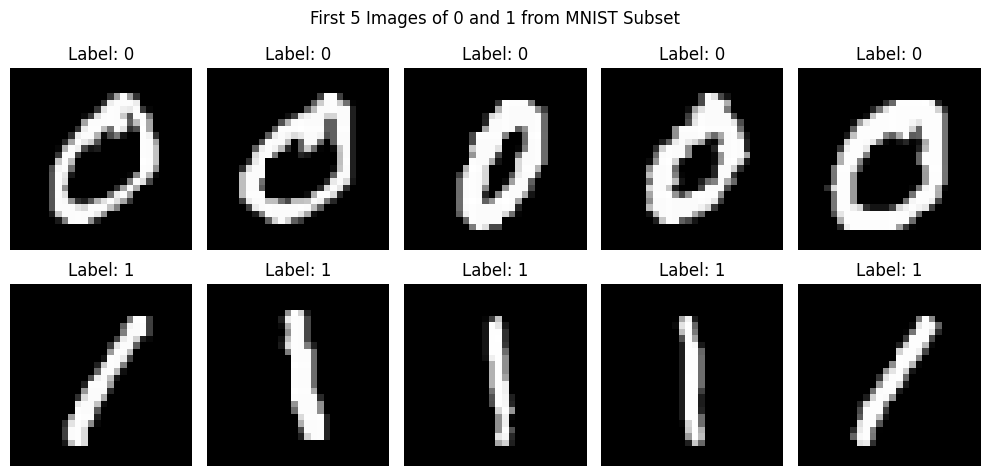

In [8]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

In [9]:
# Normalize pixel values to [0, 1]
X = X / 255.0

# Initialize weights and bias
weights       = np.zeros(X.shape[1])   # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print(f"Weights shape : {weights.shape}")
print(f"Bias          : {bias}")
print(f"Learning rate : {learning_rate}")
print(f"Epochs        : {epochs}")

Weights shape : (784,)
Bias          : 0
Learning rate : 0.1
Epochs        : 100


# QUESTION 3 - What does the weights array represent?

"""
Answer:
The weights array has shape (784,) — one weight for each pixel in the image.

Each weight w_i represents HOW IMPORTANT pixel i is for
making the classification decision (0 or 1).

- A large positive weight means that pixel strongly suggests class 1
- A large negative weight means that pixel strongly suggests class 0
- A weight near zero means that pixel is not useful for classification

During training, the perceptron adjusts these 784 weights
so that the weighted sum of pixels gives the correct prediction.
"""

# QUESTION 4 - Why initialize weights to zero? What effect could this have?

"""
Answer:
We initialize weights to zero as a simple, neutral starting point.

ADVANTAGES:
- Simple and clean starting point
- All pixels start with equal importance
- No bias towards any particular class at the start

POTENTIAL EFFECTS:
- For a perceptron, zero initialization works fine because
  the step function and error-driven updates will break the
  symmetry as soon as the first misclassification occurs
- The first wrong prediction will push weights away from zero
  in the direction that reduces the error

NOTE:
- Zero initialization can be a problem in deep neural networks
  (called the symmetry problem) because all neurons learn
  the same thing simultaneously
- But for a single perceptron it is perfectly acceptable
"""

In [10]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the step activation function.
    Parameters:
        X       : Feature matrix (n_samples, n_features)
        weights : Weight vector (n_features,)
        bias    : Bias scalar
    Returns:
        y_pred_all: Predicted labels (0 or 1) for each sample
    """
    # Compute weighted sum: z = XW + b
    predictions = np.dot(X, weights) + bias

    # Apply step activation function
    y_pred_all  = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# Quick test
test_pred = decision_function(X[:5], weights, bias)
print("Sample predictions (before training):", test_pred)

Sample predictions (before training): [1 1 1 1 1]


In [11]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
        X             : Feature matrix (n_samples, n_features)
        y             : True labels (n_samples,)
        weights       : Initial weights (n_features,)
        bias          : Initial bias scalar
        learning_rate : Step size for weight updates
        epochs        : Number of passes over the dataset
    Returns:
        weights  : Updated weights after training
        bias     : Updated bias after training
        accuracy : Final training accuracy
    """
    for epoch in range(epochs):
        convergence_flag = True   # assume converged unless a mistake is found

        for i in range(len(X)):
            # Step 1: Compute weighted sum
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply step activation function
            y_pred = 1 if output >= 0 else 0

            # Step 3: Update weights if prediction is wrong
            if y_pred != y[i]:
                error            = y[i] - y_pred
                weights          = weights + learning_rate * error * X[i]
                bias             = bias    + learning_rate * error
                convergence_flag = False   # still making mistakes

        # Early stopping if no mistakes were made this epoch
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}")
            break

    # Compute final accuracy
    final_predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy          = np.mean(final_predictions == y)

    return weights, bias, accuracy

# QUESTION 5 - Purpose of: output = np.dot(X[i], weights) + bias
Answer:
This line computes the WEIGHTED SUM (also called the net input or logit)
for one training sample X[i].

np.dot(X[i], weights) multiplies each pixel value by its corresponding
weight and sums all 784 results together:

  output = x1*w1 + x2*w2 + x3*w3 + ... + x784*w784 + bias

This is the z = XW + b equation we saw in Softmax Regression.
The result is a single number that represents the perceptron's
raw confidence before the activation function is applied.
- Large positive output → likely class 1
- Large negative output → likely class 0

# QUESTION 6 - What happens when prediction is wrong? Weight update?
Answer:
When y_pred != y[i], the prediction is wrong and we update:

  error    = y[i] - y_pred      ← can be +1 or -1

  weights  = weights + learning_rate * error * X[i]
  bias     = bias    + learning_rate * error

CASES:
  If true label = 1 but predicted = 0:
    error = +1
    weights INCREASE for active pixels → pushes output higher → more likely to predict 1

  If true label = 0 but predicted = 1:
    error = -1
    weights DECREASE for active pixels → pushes output lower → more likely to predict 0

The bias shifts the decision boundary up or down accordingly.
The perceptron keeps adjusting until all samples are correct
or the maximum number of epochs is reached.

# QUESTION 7 - Why is final accuracy important? What do we expect?
Answer:
Final accuracy tells us HOW WELL the perceptron has learned to
separate the two classes on the training data.

For 0 vs 1 classification:
  We expect VERY HIGH accuracy (close to 100%) because:
  - Digits 0 and 1 look very different visually
  - 0 is round/oval shaped, 1 is thin and vertical
  - These pixel patterns are very distinct
  - The data is likely LINEARLY SEPARABLE
  - The perceptron convergence theorem guarantees 100% accuracy
    if the data is linearly separable

If accuracy is low, it means either:
  - The data is not linearly separable
  - More epochs are needed
  - The learning rate needs adjusting


In [12]:
# Train the perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                            learning_rate=learning_rate,
                                            epochs=epochs)

print(f"Final Training Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

Converged at epoch 16
Final Training Accuracy: 1.0000  (100.00%)


In [13]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

# Final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualize misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 0 vs 1")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(misclassified_idx)}")
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# QUESTION 8 - What does misclassified_idx store and how is it used?
Answer:
misclassified_idx = np.where(y_pred != y)[0]

np.where(y_pred != y) finds every position (index) where
the predicted label does NOT match the true label.

The [0] at the end extracts the array of indices from the
tuple that np.where returns.

Example:
  y      = [0, 1, 0, 1, 0]
  y_pred = [0, 0, 0, 1, 1]
                 ↑        ↑
  misclassified_idx = [1, 4]

HOW IT IS USED:
  - misclassified_idx[:10] takes the first 10 wrong predictions
  - X[idx].reshape(28,28) retrieves and reshapes that image
  - The title shows what the model predicted vs the true label
  - This helps us visually inspect WHERE the model goes wrong
    and WHY (e.g. ambiguous handwriting)

# QUESTION 9 - How to interpret "All images were correctly classified!"?
Answer:
This message means the perceptron achieved 100% training accuracy.

INTERPRETATION:
  - The perceptron found a linear decision boundary that
    perfectly separates ALL 0s from ALL 1s in the dataset
  - This is consistent with the Perceptron Convergence Theorem:
    if data is linearly separable, the perceptron WILL converge
    to a perfect solution in a finite number of steps

FOR 0 vs 1:
  - This outcome is expected because 0 and 1 are visually
    very different digits
  - Their pixel patterns are distinct enough for a linear
    boundary to separate them perfectly

IMPORTANT NOTE:
  - This is TRAINING accuracy, not test accuracy
  - The model might still make mistakes on new unseen images
  - Perfect training accuracy could also mean the model
    has overfitted to the training data

Feature matrix shape : (13454, 784)
Label vector shape   : (13454,)
Unique labels        : [3 5]


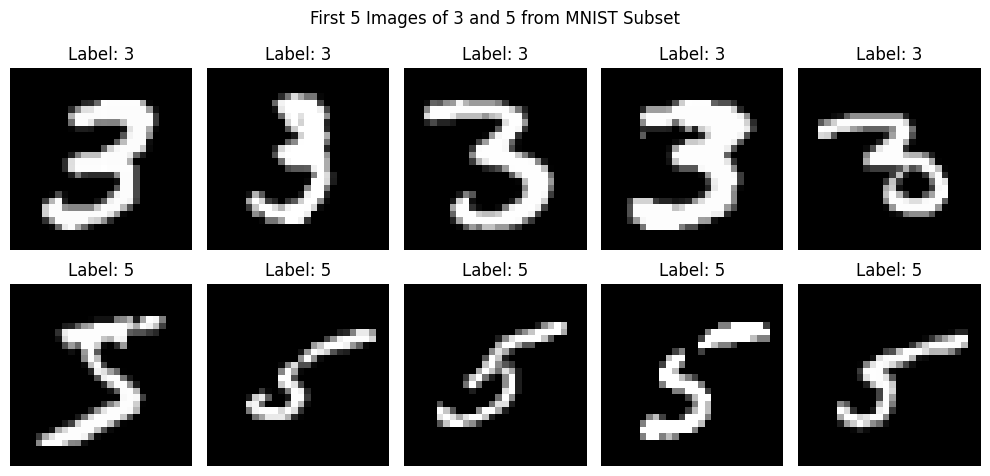

In [14]:
# TASK 3 - Perceptron for 3 vs 5 Classification

# Step 1: Load dataset
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

X_35   = df_3_5.drop(columns=["label"]).values
y_35   = df_3_5["label"].values

print(f"Feature matrix shape : {X_35.shape}")
print(f"Label vector shape   : {y_35.shape}")
print(f"Unique labels        : {np.unique(y_35)}")

# Step 2: Normalize
X_35 = X_35 / 255.0

# Step 3: Visualize
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [15]:
# Step 4: Convert labels - perceptron needs binary (0 or 1)
# Map: 3 → 0,  5 → 1
y_35_binary = np.where(y_35 == 3, 0, 1)

# Step 5: Initialize weights and bias
weights_35       = np.zeros(X_35.shape[1])
bias_35          = 0
learning_rate_35 = 0.1
epochs_35        = 100

# Step 6: Train
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary,
    weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)

print(f"Final Training Accuracy (3 vs 5): {accuracy_35:.4f}  ({accuracy_35*100:.2f}%)")

Final Training Accuracy (3 vs 5): 0.9587  (95.87%)


Final Accuracy: 0.9587


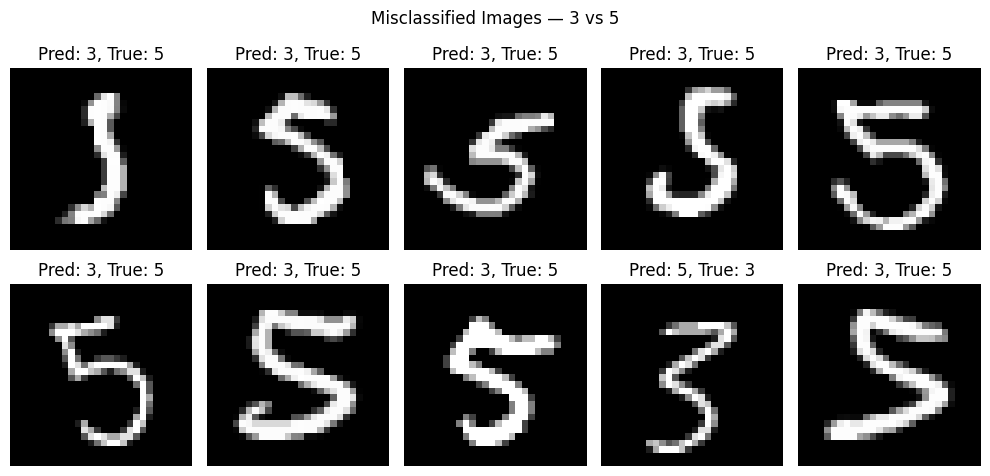

Total misclassified: 555


In [16]:
# Get predictions
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35      = np.where(predictions_35 >= 0, 1, 0)

# Convert binary predictions back to original labels for display
y_pred_labels  = np.where(y_pred_35 == 0, 3, 5)
y_true_labels  = y_35

# Final accuracy
final_acc_35   = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy: {final_acc_35:.4f}")

# Visualize misclassified images
misclassified_35 = np.where(y_pred_labels != y_true_labels)[0]

if len(misclassified_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_labels[idx]}, True: {y_true_labels[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 3 vs 5")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(misclassified_35)}")
else:
    print("All images were correctly classified!")

In [17]:
# CONCLUSION - Perceptron on 3 vs 5 Classification
"""
OBSERVATION:
  The perceptron performs noticeably worse on 3 vs 5 classification
  compared to 0 vs 1 classification.

WHY IS 3 vs 5 HARDER?
  - Digits 3 and 5 share very similar visual structure
  - Both have curved strokes and similar pixel distributions
  - The difference between them is subtle (direction of curves)
  - A linear boundary struggles to separate them perfectly

MISCLASSIFIED IMAGES:
  - The misclassified images show cases where 3 and 5 look
    very similar — ambiguous handwriting styles
  - The perceptron confuses 3 for 5 and vice versa because
    their pixel patterns overlap significantly

WHAT THIS TELLS US ABOUT THE PERCEPTRON:
  - If data is NOT perfectly linearly separable, the perceptron
    may NOT converge to 100% accuracy
  - It will keep oscillating around a near-optimal solution
  - A more powerful model (e.g. multi-layer neural network)
    would be needed to capture the non-linear decision boundary
    between 3 and 5

COMPARISON:
  Task             | Expected Accuracy
  -----------------|------------------
  0 vs 1           | ~99-100% (very separable)
  3 vs 5           | ~90-95%  (less separable)
"""

print("Conclusion documented above.")
print(f"\nSummary:")
print(f"  0 vs 1 Final Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  3 vs 5 Final Accuracy : {accuracy_35:.4f}  ({accuracy_35*100:.2f}%)")

Conclusion documented above.

Summary:
  0 vs 1 Final Accuracy : 1.0000  (100.00%)
  3 vs 5 Final Accuracy : 0.9587  (95.87%)
